<a href="https://colab.research.google.com/github/salometoroc-cmd/Estructura-de-bases-de-datos-/blob/main/Lab%20%C3%A1rboles%20QuadTree/Arboles_quad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

21/04/2026

Salomé Toro Cadavid

# Arbol-Quadtree

Es una estructura de datos que divide un espacio en 4 cuadrantes una y otra vez, como si estuvieras partiendo una hoja en 4 partes iguales repetidamente. Cada cuadrante puede volver a dividirse si tiene muchos puntos. Esto permite organizar puntos en el plano para buscarlos más rápido.Se usan el videojuegos,robótica,sistemas de mapas, entre otros.

Para el código se reliza una clase nodo y una clase arbol, en esta se encuentra las funciones más importantes como:

 construir en la cual secibe una lista de puntos y los va ubicando en los cuadrantes  según su posición X, Y; se detiene cuando un cuadrante tiene 1 punto o menos, o cuando llega a una profundidad máxima.

Bucar por radio con un punto objetivo y un radio, encuentra todos los puntos que están dentro de ese círculo,se intentó implementar que  revisé los cuadrantes que podrían contener puntos dentro del radio.

Buscar al vecino más cercano que con un punto objetivo, encuentra el punto más cercano a él en todo el espacio.


In [181]:
import math

class nodo:
  def __init__(self,puntos,Xminimo,Xmaximo,Yminimo,Ymaximo):  #define que para crar un nodo se necesita los puntos
      self.puntos =   puntos                                 #un minimo, un maximo en y como en x
      self.Xminimo = Xminimo
      self.Xmaximo = Xmaximo
      self.Yminimo = Yminimo
      self.Ymaximo = Ymaximo
      self.mitadX =  (Xminimo + Xmaximo) /2                  #para encontrar la mitad en cada eje sumamos sus extremos y dividimos para y y x y así dividimos el árbol, es decir el punto medio
      self.mitadY =  (Yminimo + Ymaximo) /2
      self.arriba_derecha = None                             #define subcuadrantes en los que pueden estar los puntos ubicados
      self.arriba_izquierda = None
      self.abajo_derecha = None
      self.abajo_izquierda = None

class quadTree:
  def __init__(self,puntos,Xminimo,Xmaximo,Yminimo,Ymaximo,profundidad):         #para crear el quadtree definimos los puntos, maximos y profundidad
    self.puntos = puntos
    self.Xminimo = Xminimo
    self.Xmaximo = Xmaximo
    self.Yminimo = Yminimo
    self.Ymaximo = Ymaximo
    self.profundidad = profundidad                                              # esta profunidad nos ayudara para ver y controlaar cuantas veces hay que dividir el subcuadrante o subcuadrantes
    self.raiz = self.construir(puntos,Xminimo,Xmaximo,Yminimo,Ymaximo,profundidad)    #construimos la raiz apartir de la funcion contruir

  def construir(self,puntos,Xminimo,Xmaximo,Yminimo,Ymaximo,profundidad):
    if len(puntos) <= 1 or profundidad == 0:
      return nodo(puntos, Xminimo, Xmaximo, Yminimo, Ymaximo)

    mitadX =  (Xminimo + Xmaximo) /2
    mitadY =  (Yminimo + Ymaximo) /2     # Se calcula el punto medio para dividir el espacio en 4 cuadrantes iguales
    Sección_arriba_derecha=[]
    Sección_arriba_izquierda=[]                             # Listas para almacenar los puntos según el cuadrante
    Sección_abajo_derecha=[]
    Sección_abajo_izquierda=[]

    for punto in puntos:                                            # Recorremos la lista de puntos y se  clasifica cada punto en uno de los 4 cuadrantes teniendo en cuenta los puntos medios
      if punto.x > mitadX and punto.y >= mitadY:
        Sección_arriba_derecha.append(punto)
      elif punto.x <= mitadX and punto.y >= mitadY:
        Sección_arriba_izquierda.append(punto)
      elif punto.x > mitadX and punto.y < mitadY:
        Sección_abajo_derecha.append(punto)
      else:
        Sección_abajo_izquierda.append(punto)

    nodo_actual = nodo([],Xminimo,Xmaximo,Yminimo,Ymaximo)   # Se crea el nodo actual con la región correspondiente

    nodo_actual.arriba_izquierda = self.construir(Sección_arriba_izquierda, Xminimo,mitadX,mitadY, Ymaximo, profundidad - 1)    # Llamadas recursivas para construir los 4 subárboles y seguir dentro de ellos
    nodo_actual.arriba_derecha = self.construir(Sección_arriba_derecha, mitadX,Xmaximo,mitadY,Ymaximo,profundidad - 1)
    nodo_actual.abajo_derecha = self.construir(Sección_abajo_derecha, mitadX,Xmaximo,Yminimo,mitadY,profundidad - 1)
    nodo_actual.abajo_izquierda = self.construir(Sección_abajo_izquierda, Xminimo,mitadX,Yminimo,mitadY, profundidad - 1)

    return nodo_actual

  def distancia_punto_rectangulo(self, px, py, nodo_actual): #recibe coordenadas y un nodo que tiene el rectangulo
    dx = max(0, nodo_actual.Xminimo - px, px - nodo_actual.Xmaximo) #distancia en x
    dy = max(0, nodo_actual.Yminimo - py, py - nodo_actual.Ymaximo) #distancia en y
    return math.sqrt(dx*dx + dy*dy)   #formula para la distancia

  def buscarR(self,nodo_actual,punto_Ob,radio):   #usa el nodo actual, el punto objetivo y el radio
    if nodo_actual is None :
      return []
    x, y = punto_Ob              #el punto objetivo se compone de un x y un y
    if self.distancia_punto_rectangulo(x, y, nodo_actual) > radio:
      return []
    puntos_en_el_radio = []     #lista para poner los puntos que se encuentran en el radio

    for punto in nodo_actual.puntos:      #  verificamos los puntos del nodo
      distancia = math.sqrt((punto.x - x)**2 + (punto.y - y)**2)   #calculamos las distancia y vemos si entra en el radio
      if distancia <= radio:
        puntos_en_el_radio.append(punto)

    arriba_derecha = self.buscarR(nodo_actual.arriba_derecha,punto_Ob,radio)   #realizamos la busqueda para los cuadrantes  y luego agregamos todos lo puntos encontrados a la lista
    puntos_en_el_radio.extend(arriba_derecha)
    arriba_izquierda = self.buscarR(nodo_actual.arriba_izquierda, punto_Ob,radio)
    puntos_en_el_radio.extend(arriba_izquierda)
    abajo_derecha = self.buscarR(nodo_actual.abajo_derecha, punto_Ob,radio)
    puntos_en_el_radio.extend(abajo_derecha)
    abajo_izquierda = self.buscarR(nodo_actual.abajo_izquierda,punto_Ob,radio)
    puntos_en_el_radio.extend(abajo_izquierda)

    return puntos_en_el_radio


  def buscar_VecinoCercano(self, nodo_actual, punto_Ob, mejor_distancia=float('inf')):
    if nodo_actual is None:
        return None, float('inf')

    x, y = punto_Ob
    mejor_punto = None

    # Revisar puntos del nodo actual
    for punto in nodo_actual.puntos:
        distancia = math.sqrt((punto.x - x)**2 + (punto.y - y)**2)
        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_punto = punto

    # Cuadrantes
    cuadrantes = [
        nodo_actual.arriba_derecha,
        nodo_actual.arriba_izquierda,
        nodo_actual.abajo_derecha,
        nodo_actual.abajo_izquierda]

    for cuadrante in cuadrantes:
        if cuadrante is None:
            continue

        # Si el cuadrante está más lejos que la mejor distancia, lo salta
        if self.distancia_punto_rectangulo(x, y, cuadrante) >= mejor_distancia:
            continue  # Salta este cuadrante completo

        punto_cerca, dist_cerca = self.buscar_VecinoCercano(cuadrante, punto_Ob, mejor_distancia)
        if dist_cerca < mejor_distancia:
            mejor_distancia = dist_cerca
            mejor_punto = punto_cerca

    return mejor_punto, mejor_distancia

# Test

###**Fuerza** **bruta**

Para la comparación con fuerza bruta, se intenta hacer el método de las listas que es completamente distinto, ya que en el recolectamos y recorremos por medio de lista.

Hay dos funciones al igual que en el arbol, estas son buscar por radio y buscal al vecino más cercano ya que el tiempo lo queremos para comparar.

la funcion de busqueda por radio realiza una lista de los puntos que se encuntran pero debe de recorrecar cada punto y comparar, por otra parte la función de vecino más cercano tambien comparar cada uno y va actualizan si realmente es el más cercano

In [182]:
import math

def fuerza_bruta_buscarR(puntos, punto_Ob, radio):
    puntos_en_radio = []   # lista para los punto que estan en el radio
    x, y = punto_Ob  #x y y en el punto objetivo
    for punto in puntos:
        distancia = math.sqrt((punto.x - x)**2 + (punto.y - y)**2)  #para cada punto se miden distancias y se comparan quienes si estan dentro
        if distancia <= radio:
            puntos_en_radio.append(punto)
    return puntos_en_radio
resultado_Fradio = fuerza_bruta_buscarR(puntos, (5000, 2000), 5000)


def fuerza_bruta_vecinoCercano(puntos, punto_Ob):
    if not puntos:
        return None, float('inf')
    mejor_punto = None
    mejor_dist = float('inf')
    x, y = punto_Ob
    for punto in puntos:  #tambien se comparan distancias y se actualiza con la que sea mejor o más cercana
        dist = math.sqrt((punto.x - x)**2 + (punto.y - y)**2)
        if dist < mejor_dist:
            mejor_dist = dist
            mejor_punto = punto
    return mejor_punto, mejor_dist
resultado_Fvecino = fuerza_bruta_vecinoCercano(puntos, (5000, 2000))

###**Pruebas**

Para la prueba se busca el punto objetivo (5000,2000), con un radio de 500 y lo que va a variar es n que son los numeros de datos para 1000,5000,10000 y 20000, esto con la finalidad de ver que tanto pueden variar lo tiempos con respecto a la cantidad de datos, se ejecutara 3 veces con cada cantidad de datos para luego sacar un promedio, que estará en la ubicado en la tabla comprartiva .

In [183]:
import time  #importo time para poder contar lo tiempos que luego sirven para las comparaciones con promedios
import random

# Define la clase punto
class Punto:
    def __init__(self, x, y):
        self.x = x
        self.y = y

punto_objetivo = (5000, 2000)
radio =500
n = 10000
random.seed(42)

  # generar puntos
puntos = [Punto(random.randint(0,10000), random.randint(0,10000)) for _ in range(n)]
arbol = quadTree(puntos, 0, 10000, 0, 10000, 6)
inicio = time.time()  # árbol radio y contar tiempo en todas
resultado_arbol = arbol.buscarR(arbol.raiz, punto_objetivo, radio)
fin = time.time()
tiempo_arbol_radio = fin - inicio


inicio = time.time() # árbol vecino
vecino_arbol, dist_arbol = arbol.buscar_VecinoCercano(arbol.raiz, punto_objetivo)
fin = time.time()
tiempo_arbol_vecino = fin - inicio

inicio = time.time()  # fuerza bruta radio
resultado_bruta = fuerza_bruta_buscarR(puntos, punto_objetivo, radio)
fin = time.time()
tiempo_bruta_radio = fin - inicio


inicio = time.time()  # fuerza bruta vecino
vecino_bruta, dist_bruta = fuerza_bruta_vecinoCercano(puntos, punto_objetivo)
fin = time.time()
tiempo_bruta_vecino = fin - inicio


print("numero de puntos entro el radio")
print("En el árbol : ")
print(len(resultado_arbol))
print("Fuerza bruta : ")
print(len(resultado_bruta))

print("diatancia del vecino más cercano")
print("Árbol ")
print(dist_arbol)
print("Fuerza bruta ")
print(dist_bruta)

print("punto vecino más cercano")
print(vecino_arbol.x, vecino_arbol.y)
print(vecino_bruta.x, vecino_bruta.y)

print("tiempos")
print("Árbol radio:", tiempo_arbol_radio)
print("Fuerza bruta radio:", tiempo_bruta_radio)
print("Árbol vecino:", tiempo_arbol_vecino)
print("Fuerza bruta vecino:", tiempo_bruta_vecino)


numero de puntos entro el radio
En el árbol : 
82
Fuerza bruta : 
82
diatancia del vecino más cercano
Árbol 
41.88078318274385
Fuerza bruta 
41.88078318274385
punto vecino más cercano
5023 1965
5023 1965
tiempos
Árbol radio: 0.000423431396484375
Fuerza bruta radio: 0.0038690567016601562
Árbol vecino: 0.0013885498046875
Fuerza bruta vecino: 0.0035338401794433594


###**Graficas**

Las graficas representan cada uno de los puntos que se encuentran dependiendo de la cantidad, en la grafica de la de radio, muestra un radio de 500 y dentro están los puntos dentro de él , y igualmente el punto objetivo.Por otro lado la grafica de el vecino, muestra el punto objetivo, el vecino más cercano y la distancia que tienen







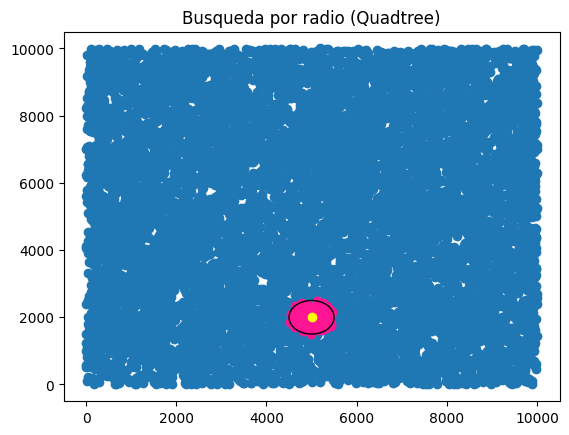

In [184]:
import matplotlib.pyplot as plt

punto = (5000, 2000)
radio = 500

# resultados con tu quadtree
resultados = arbol.buscarR(arbol.raiz, punto, radio)

# listas de todos los puntos
x = []
y = []
for p in puntos:
    x.append(p.x)
    y.append(p.y)

# puntos dentro del radio
x_radio = []
y_radio = []
for p in resultados:
    x_radio.append(p.x)
    y_radio.append(p.y)

# graficar
plt.scatter(x, y)
plt.scatter(x_radio, y_radio, color="deeppink")
plt.scatter(punto[0], punto[1], color="yellow")

circulo = plt.Circle((punto[0], punto[1]), radio, fill=False)
plt.gca().add_patch(circulo)

plt.title("Busqueda por radio (Quadtree)")
plt.show()

Vecino más cercano: 5023 1965
Distancia: 41.88078318274385
Tiempo: 0.0033531169974594377


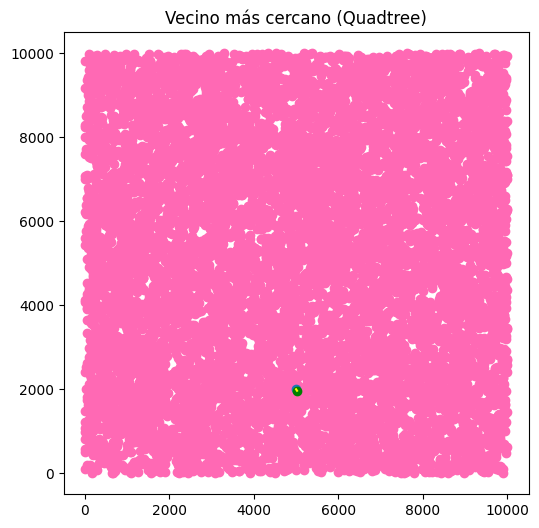

In [185]:
import time
import matplotlib.pyplot as plt

punto = (5000, 2000)

# medir tiempo quadtree
inicio = time.perf_counter()
vecino, distancia = arbol.buscar_VecinoCercano(arbol.raiz, punto)
fin = time.perf_counter()
tiempo_final_vecinoCercano = fin - inicio

print("Vecino más cercano:", vecino.x, vecino.y)
print("Distancia:", distancia)
print("Tiempo:", tiempo_final_vecinoCercano)

# graficar
x = []
y = []
for p in puntos:
    x.append(p.x)
    y.append(p.y)

plt.figure(figsize=(6,6))

plt.scatter(x, y, color="hotpink")  # todos los puntos

plt.scatter(punto[0], punto[1])  # punto objetivo

plt.scatter(vecino.x, vecino.y, color="green")  # vecino más cercano

plt.plot([punto[0], vecino.x], [punto[1], vecino.y], color="yellow")  # línea distancia

plt.title("Vecino más cercano (Quadtree)")
plt.show()

###**Cuadro** **comparativo   1**

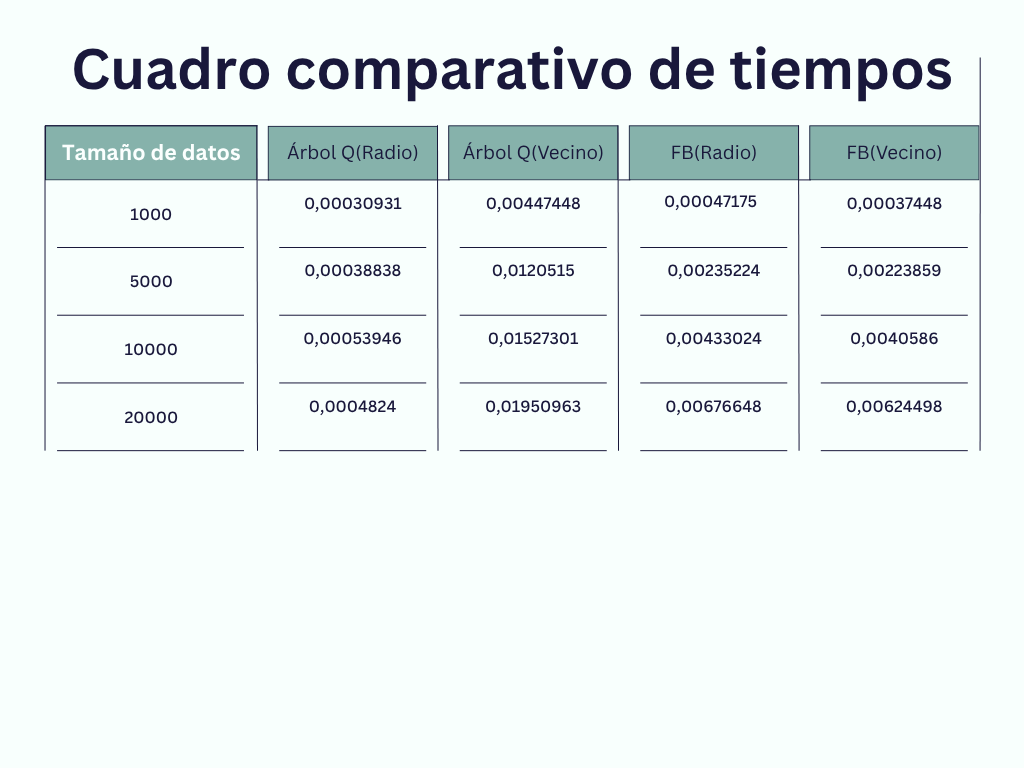

###**Cuadro comparativo 2**

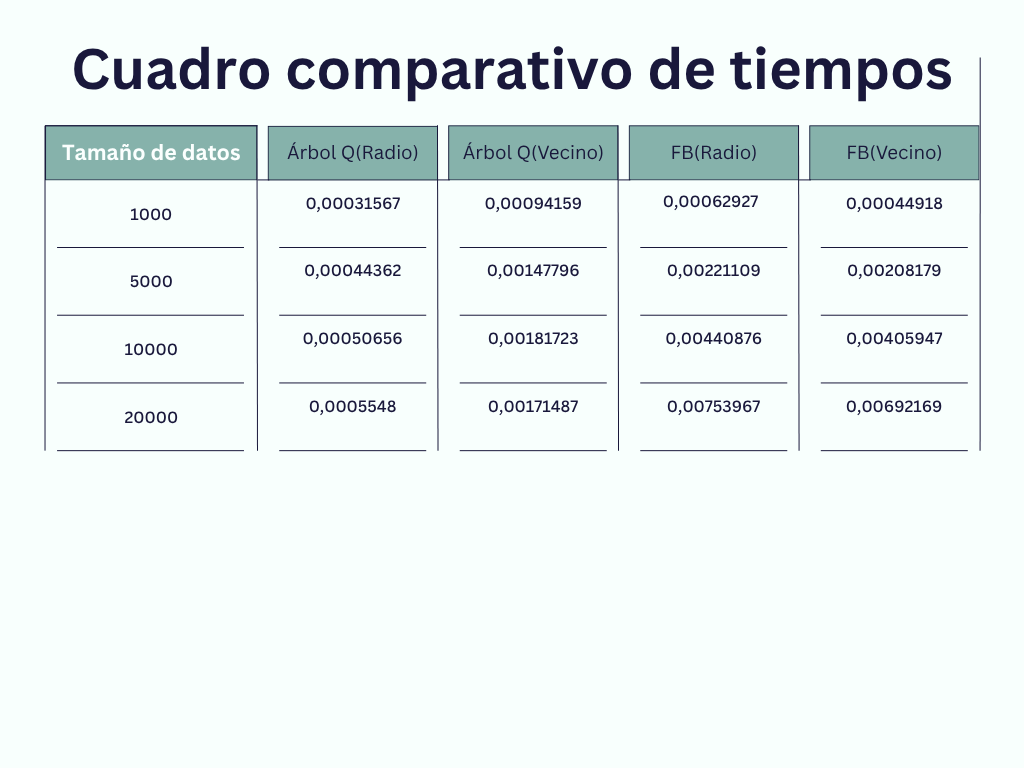

# **Analisis y discución de resultados**

**-Graficas:**

A medida que el tamaño de los datos aumenta, se identifica una gran cantidad de puntos; si hay muy pocos puntos, se observa que la búsqueda puede ser un poco más larga, ya que, aunque puede descartar o podar nodos, debe segmentar bastantes cuadrantes para poder identificar estos puntos.


**-Cuadro comparativo   1:**

En este primer cuadro se observa una comparación de árbol Quadtree vs. fuerza bruta, donde se compara tanto el tiempo promedio de buscar por radio de ambas como buscar el vecino más cercano, teniendo en cuenta cómo se relaciona que haya distinta cantidad de datos.




En la búsqueda por radio del QuadTree se muestra un mejor rendimiento que la fuerza bruta, siendo 1.525 veces más rápido. Esto es debido a que se implementa correctamente la poda de nodos por la función de rectángulo, donde se evita explorar cuadrantes que no intersectan el radio de búsqueda.




En la búsqueda del vecino más cercano, se identifica una inconsistencia entre teoría y práctica, debido a que el tiempo de fuerza es mejor que el del árbol con 11.95, siendo más lento el árbol. Esto debido a que el árbol está recorriendo cada punto verificando los datos y no los está descartando, lo que está generando un mayor costo computacional, posiblemente de N^2.



**-cuadro comparativo   2**

Este segundo cuadro se realizó con la finalidad de mostrar cómo cambia el código al visualizar el error anterior sobre la búsqueda del vecino más cercano; aquí ahora podemos identificar que sí se realiza una poda donde no se ve punto por punto, sino que salta aquellos que no se relacionan. Aquí ya observamos que el tiempo del árbol es menor en comparación con la fuerza en los 20000 datos: 4.04 más rápido


**-Errores,posibles problemas y dificultades**

- Error inicial en la poda del vecino más cercano: se recorría cada punto sin usar la distancia mínima para descartar cuadrantes.

- Una de las principales dificultades del laboratorio fue comprender y aplicar la lógica del árbol; por esta razón, se recorrieron partes del árbol innecesarias.

